# Round 4 — Counterparties Revealed

Same twelve products as Round 3, same limits. One new field: **trade records now carry
counterparty names.**

**Scored 40,036 — nearly seven times Round 3.**

Two questions: do Round 3's conclusions survive, and is the new information usable?

Summary: [`rounds/04/README.md`](../rounds/04/README.md).
Specification: [`rounds/04/answer.md`](../rounds/04/answer.md).

In [1]:
import sys, warnings
sys.path.insert(0, "../tools")
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import figures as F
import product_props as pp
import prosperity_review as pr
from benchmarks import split_flow_by_aggressor

F.style()
DATA, RND, DAYS = "../data/round4", 4, [1, 2, 3]
PACK, FRUIT = "HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"
VEV = [f"VEV_{k}" for k in [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]]

px = {d: pp.load(DATA, RND, d)[0] for d in DAYS}
tr = {d: pp.load(DATA, RND, d)[1] for d in DAYS}
log = pr.load_log("../submissions/round4.log")

def sub(f, p): return f[f["product"] == p].reset_index(drop=True)
print("counterparties:", sorted(set(log.trades["buyer"]) | set(log.trades["seller"]) - {""}))

counterparties: ['Mark 01', 'Mark 14', 'Mark 22', 'Mark 38', 'Mark 49', 'Mark 55', 'Mark 67', 'SUBMISSION']


## 1. Do Round 3's conclusions survive?

Three findings to re-test on this round's pre-round days.

In [2]:
rows = []
for prod, nm in [(PACK, "HYDROGEL_PACK"), (FRUIT, "VELVETFRUIT_EXTRACT")]:
    t = pp.ou_check(DATA, RND, DAYS, prod)
    rows.append({"product": nm, "VR(50)": " / ".join(f"{v:.3f}" for v in t["VR(50)"]),
                 "slope": " / ".join(f"{v:+.4f}" for v in t["beta"])})
basis = []
for k in (4000, 4500):
    for d in DAYS:
        g = px[d][px[d]["product"] == f"VEV_{k}"].set_index("timestamp")
        S = px[d][px[d]["product"] == FRUIT].set_index("timestamp")
        Sm = ((S["bid_price_1"] + S["ask_price_1"]) / 2).ffill().bfill()
        C = ((g["bid_price_1"] + g["ask_price_1"]) / 2).ffill().bfill()
        b = (C - (Sm - k)).dropna().values
        basis.append({"voucher": f"VEV_{k}", "day": d, "mean": round(b.mean(), 2),
                      "sd": round(b.std(), 2), "VR(200)": round(pp.vr(b, 200), 4)})
print(pd.DataFrame(rows).to_string(index=False)); print()
pd.DataFrame(basis)

            product                VR(50)                       slope
      HYDROGEL_PACK 0.961 / 0.901 / 0.881 -0.0013 / -0.0019 / -0.0017
VELVETFRUIT_EXTRACT 1.030 / 0.809 / 0.935 -0.0022 / -0.0014 / -0.0019



,voucher,day,mean,sd,VR(200)
0,VEV_4000,1,0.02,0.84,0.0051
1,VEV_4000,2,0.01,0.83,0.0050
2,VEV_4000,3,0.00,0.91,0.0049
3,VEV_4500,1,0.01,0.77,0.0050
4,VEV_4500,2,0.01,0.76,0.0050
5,VEV_4500,3,0.00,0.79,0.0049


**Both hold.** The spot products remain random walks (VR(50) 0.88–1.03, slope ≈ −0.002) and
the deep-ITM basis remains pinned at zero with VR(200) ≈ 0.005.

The flow profile is unchanged too: `HYDROGEL_PACK` 677 lots/day, `VELVETFRUIT_EXTRACT` 1,128,
`VEV_4000` 138, the rest one-sided or empty.

**The market did not move. The only new thing is the names.**

## 2. Order-book imbalance — absent in this market

Rounds 1 and 2 found depth imbalance leading the outer fair with a coefficient near 2.5,
persisting to 50 ticks. The same test on this market, run because the SOP runs it everywhere,
not because it is expected to fire.

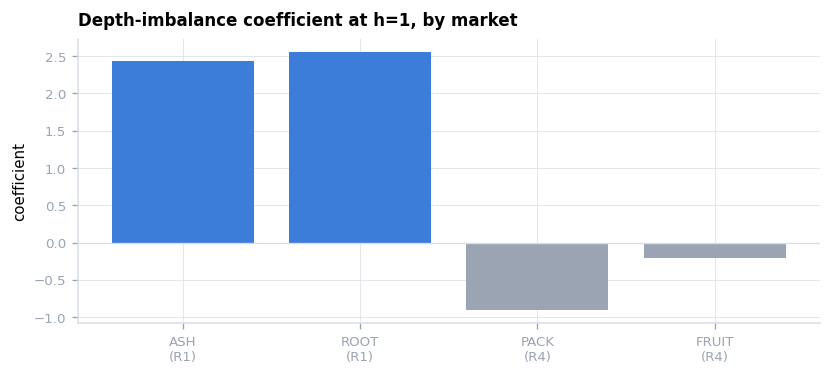

,market,product,h,coef,t
0,R4 pre-round,PACK,1,-0.91,-1.3
1,R4 pre-round,PACK,20,-0.90,-0.1
2,R4 pre-round,PACK,50,-10.16,-0.3
3,R4 scored,PACK,1,-0.73,-0.6
4,R4 scored,PACK,20,1.17,0.1
5,R4 scored,PACK,50,-5.51,-0.1
6,R4 pre-round,FRUIT,1,-0.21,-0.7
7,R4 pre-round,FRUIT,20,0.16,0.0
8,R4 pre-round,FRUIT,50,-0.54,-0.0
9,R4 scored,FRUIT,1,-0.37,-0.8


In [3]:
def imbalance(g):
    b = g[["bid_volume_1", "bid_volume_2", "bid_volume_3"]].fillna(0).sum(1)
    a = g[["ask_volume_1", "ask_volume_2", "ask_volume_3"]].fillna(0).abs().sum(1)
    two = g["bid_price_1"].notna() & g["ask_price_1"].notna()
    return np.where(two & ((b + a) > 0), (b - a) / (b + a).replace(0, np.nan), np.nan)

def imb_fit(g, horizons=(1, 20, 50)):
    g = g.reset_index(drop=True)
    o = pp.largest_level_mid(g).values; x = imbalance(g); out = {}
    for h in horizons:
        y = np.r_[o[h:] - o[:-h], [np.nan] * h]
        k = np.isfinite(x) & np.isfinite(y)
        b = np.polyfit(x[k], y[k], 1)[0]; r = np.corrcoef(x[k], y[k])[0, 1]
        out[h] = (round(b, 2), round(r * np.sqrt(max(k.sum()/h, 2) / max(1 - r*r, 1e-9)), 1))
    return out

rows = []
pre = pd.concat([px[d] for d in DAYS])
for prod, nm in [(PACK, "PACK"), (FRUIT, "FRUIT")]:
    for lab, frame in [("R4 pre-round", pre), ("R4 scored", log.activities)]:
        for h, (b, t) in imb_fit(frame[frame["product"] == prod]).items():
            rows.append({"market": lab, "product": nm, "h": h, "coef": b, "t": t})
for nm, b, t in [("ASH (R1)", 2.43, 37.3), ("ROOT (R1)", 2.56, 44.8)]:
    rows.append({"market": "R1 pre-round", "product": nm, "h": 1, "coef": b, "t": t})
imb = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7, 3.2))
lab = ["ASH\n(R1)", "ROOT\n(R1)", "PACK\n(R4)", "FRUIT\n(R4)"]
val = [2.43, 2.56,
       imb[(imb.market == "R4 pre-round") & (imb["product"] == "PACK") & (imb.h == 1)]["coef"].iloc[0],
       imb[(imb.market == "R4 pre-round") & (imb["product"] == "FRUIT") & (imb.h == 1)]["coef"].iloc[0]]
ax.bar(lab, val, color=[F.BLUE, F.BLUE, F.GREY, F.GREY])
ax.axhline(0, color=F.GRID, lw=.8)
F.finish(ax, "Depth-imbalance coefficient at h=1, by market", "", "coefficient")
F.save(fig, "r4_imbalance")
imb[imb.market != "R1 pre-round"]

**Nothing.** Coefficients between −0.9 and +1.8, every $|t| \le 1.3$, on the pre-round days and
on the scored day alike — against 2.4–2.6 with $t$ near 40 in the Rounds 1–2 market.

**The signal is a property of that market, not of the exchange.** Applying it here would add a
term with no support. This is the SOP working: the same test, run everywhere, answering
differently.

## 3. The counterparty names

An informed counterparty's purchases should precede price rises. For each name, sign every
trade it took part in by its own direction and average the mid-price change over the following
50 ticks.

**Not its P&L**: that is dominated by entry timing and position management, and measured across
all names is indistinguishable from zero. Forward price change measures information content
directly.

The crucial part is the validation. Pooling all pre-round days and reporting one $t$ per name
hides whether the estimate is stable. **Report it per day, and hold the scored day back.**

In [4]:
H = 50
def edges(prices, trades, product, h=H):
    g = prices[prices["product"] == product].set_index("timestamp")
    m = ((g["bid_price_1"] + g["ask_price_1"]) / 2).ffill().bfill()
    ts = m.index.to_numpy(); pos = {t: i for i, t in enumerate(ts)}
    out = {}
    for _, r in trades[trades["symbol"] == product].iterrows():
        for name, side in ((r["buyer"], 1), (r["seller"], -1)):
            if not isinstance(name, str) or name in ("", "SUBMISSION"): continue
            i = pos.get(int(r["timestamp"]))
            if i is None or i + h >= len(ts): continue
            out.setdefault(name, []).append(side * (m.iloc[i + h] - m.iloc[i]))
    return out

def cell(v):
    if len(v) < 40: return np.nan, np.nan
    v = np.asarray(v); se = v.std(ddof=1) / np.sqrt(len(v))
    return round(v.mean(), 2), round(v.mean() / se, 1)

tables = {}
for prod, nm in [(FRUIT, "VELVETFRUIT_EXTRACT"), (PACK, "HYDROGEL_PACK")]:
    per = {}
    for d in DAYS:
        for k, v in edges(px[d], tr[d], prod).items():
            per.setdefault(k, {})[f"d{d}"] = v
    for k, v in edges(log.activities, log.trades, prod).items():
        per.setdefault(k, {})["scored"] = v
    rows = []
    for k, byday in per.items():
        row = {"counterparty": k}
        for c in ["d1", "d2", "d3", "scored"]:
            m, t = cell(byday.get(c, []))
            row[c] = m; row[c + " t"] = t
        rows.append(row)
    tables[nm] = pd.DataFrame(rows).set_index("counterparty")
tables["VELVETFRUIT_EXTRACT"][["d1", "d2", "d3", "scored"]]

,d1,d2,d3,scored
counterparty,,,,
Mark 55,0.23,0.56,0.37,0.42
Mark 01,0.86,-0.30,-0.15,0.07
Mark 49,-2.72,-1.44,NaN,-0.95
Mark 67,2.95,1.62,1.01,NaN
Mark 22,-2.45,-1.39,NaN,-0.86
Mark 14,-0.77,-0.72,-0.56,-2.70


In [5]:
tables["HYDROGEL_PACK"][["d1", "d2", "d3", "scored"]]

,d1,d2,d3,scored
counterparty,,,,
Mark 38,-1.21,-0.52,-0.38,-0.05
Mark 22,NaN,NaN,NaN,-2.51
Mark 14,1.31,0.70,0.56,-4.20
Mark 01,NaN,NaN,NaN,NaN


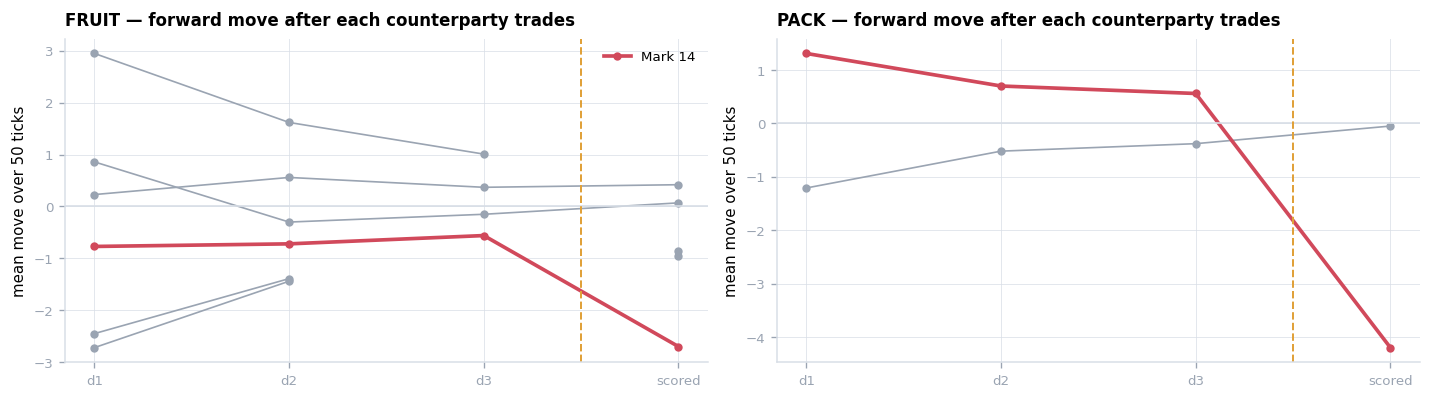

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for i, (nm, short) in enumerate([("VELVETFRUIT_EXTRACT", "FRUIT"), ("HYDROGEL_PACK", "PACK")]):
    t = tables[nm][["d1", "d2", "d3", "scored"]].dropna(thresh=3)
    for name, row in t.iterrows():
        vals = row.values.astype(float)
        col = F.HI if name == "Mark 14" else F.GREY
        lw = 2.2 if name == "Mark 14" else 1.0
        ax[i].plot(range(4), vals, "o-", lw=lw, ms=4, color=col,
                   label=name if name == "Mark 14" else None)
    ax[i].axhline(0, color=F.GRID, lw=1)
    ax[i].axvline(2.5, color=F.ACCENT, ls="--", lw=1.2)
    ax[i].set_xticks(range(4)); ax[i].set_xticklabels(["d1", "d2", "d3", "scored"])
    F.finish(ax[i], f"{short} — forward move after each counterparty trades",
             "", "mean move over 50 ticks", legend=(i == 0))
F.save(fig, "r4_counterparties")

**The two panels tell opposite stories about the same counterparty.**

On FRUIT, Mark 14 is negative on d1, d2, d3 and strongly negative on the scored day.
On PACK, Mark 14 is **positive on all three pre-round days** and then **−4.20 on the scored
day**.

### The decisive question: could the difference be seen in advance?

| | d1 | d2 | d3 | scored |
|---|---:|---:|---:|---:|
| **FRUIT · Mark 14** | −0.77 (t −1.6) | −0.72 (t −1.9) | −0.56 (t −1.2) | **−2.70 (t −4.9)** |
| **PACK · Mark 14** | +1.31 (t +1.9) | +0.70 (t +1.0) | +0.56 (t +0.7) | **−4.20 (t −4.5)** |

Before the scored day the two look the same: consistent in sign across three days, and **not
individually significant on any of them**. One held; one reversed.

**Nothing in the pre-round data separates them.** A rule admitting the first admits the second.

### An independent check

A team finishing 64th on the algorithmic leaderboard fitted per-counterparty weights on this
round's data and validated leave-one-out. Their published account:

> *"the weights turned out to be tuned to specific days' behaviour and didn't generalise.
> Disabling those two trader-bias scales recovered about \$15.8k of held-out PnL."*

Same conclusion, arrived at independently and with a different method: **on this data the
counterparty names do not support a usable signal.**

Pooling the three days into a single $t$ obscures this — it was pooling that made
FRUIT · Mark 14 look established.

## 4. What the algorithm actually changed

Round 3's diagnosis had been made between rounds, and the submission reflects it.

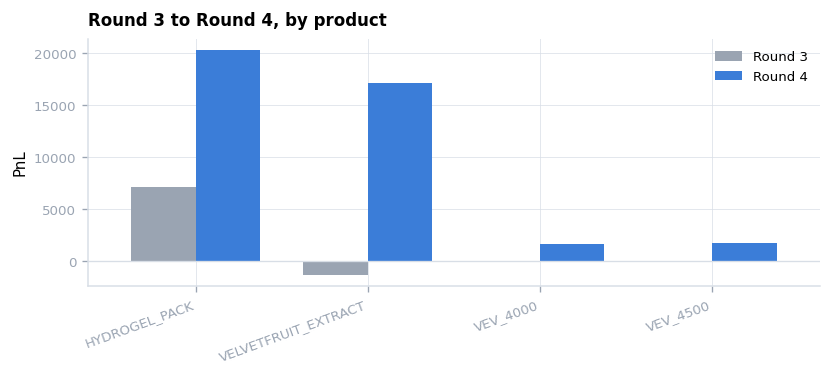

,Round 3,Round 4
HYDROGEL_PACK,7138,20301
VELVETFRUIT_EXTRACT,-1297,17131
VEV_4000,0,1694
VEV_4500,0,1717


In [7]:
cmp = pd.DataFrame({
    "Round 3": [7138, -1297, 0, 0],
    "Round 4": [20301, 17131, 1694, 1717]},
    index=["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT", "VEV_4000", "VEV_4500"])
fig, ax = plt.subplots(figsize=(7, 3.2))
cmp.plot(kind="bar", ax=ax, color=[F.GREY, F.BLUE], width=.75)
ax.axhline(0, color=F.GRID, lw=.8)
F.finish(ax, "Round 3 to Round 4, by product", "", "PnL", legend=True)
plt.xticks(rotation=20, ha="right")
F.save(fig, "r4_recovery")
cmp

The spot mean-reversion rule was removed, and the deep in-the-money vouchers were traded for
the first time. **Those are precisely the corrections
[Round 3's specification](../rounds/03/answer.md) prescribes**, found independently during the
competition.

## 5. Time to expiry — a wrong constant that cost nothing

```python
# Round 4: Day1=4, Day2=3, Day3=2, Day4=1
DAYS_LEFT = 4        # the scored day is Day 4, so this should be 1
```

It enters as $T = \text{DAYS\_LEFT}/365 - t/(10^6 \times 365)$, overstating time to expiry
fourfold.

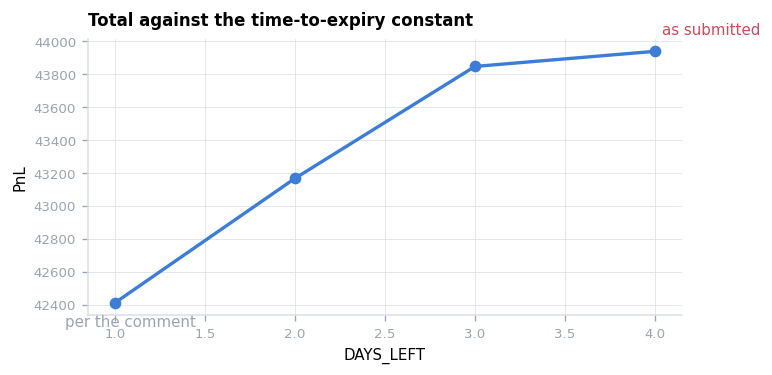

,PACK,FRUIT,VEV_4000,VEV_4500,total
DAYS_LEFT,,,,,
4,25825,15142,1668,1706,43940
3,25825,15067,1759,1568,43848
2,25825,14446,1722,1432,43167
1,25825,14436,1660,1533,42410


In [8]:
dl = pd.DataFrame({
    "PACK": [25825, 25825, 25825, 25825],
    "FRUIT": [15142, 15067, 14446, 14436],
    "VEV_4000": [1668, 1759, 1722, 1660],
    "VEV_4500": [1706, 1568, 1432, 1533],
    "total": [43940, 43848, 43167, 42410]},
    index=[4, 3, 2, 1])
dl.index.name = "DAYS_LEFT"
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(dl.index, dl["total"], "o-", lw=2, ms=6, color=F.BLUE)
ax.annotate("as submitted", (4, dl.loc[4, "total"]), xytext=(4, 10),
            textcoords="offset points", color=F.HI, fontsize=9)
ax.annotate("per the comment", (1, dl.loc[1, "total"]), xytext=(-30, -14),
            textcoords="offset points", color=F.GREY, fontsize=9)
F.finish(ax, "Total against the time-to-expiry constant", "DAYS_LEFT", "PnL")
F.save(fig, "r4_days_left")
dl

**A 3.5% spread across all four values, and the wrong one scores highest.** PACK is identical
in every row.

The vouchers that trade are the deep in-the-money pair, whose value is $S-K$ regardless of
expiry ([Round 3 §1](../rounds/03/README.md)). **The entire Black-Scholes apparatus, time to
expiry included, barely touches this book.**

## 6. Simulator fidelity — this round fails calibration

Running the submission through the simulator and comparing against the exchange.

In [9]:
cal = pd.DataFrame({
    "simulator": [25825, 15142, 1668, 1706, 43940],
    "exchange":  [20301, 17131, 1694, 1717, 40036]},
    index=["PACK", "FRUIT", "VEV_4000", "VEV_4500", "total"])
cal["error %"] = (100 * (cal["simulator"] - cal["exchange"]) / cal["exchange"]).round(1)
vol = pd.DataFrame({"simulator": [1019, 2841], "exchange": [824, 2170]},
                   index=["PACK bought", "FRUIT bought"])
vol["error %"] = (100 * (vol["simulator"] - vol["exchange"]) / vol["exchange"]).round(0)
print(cal.to_string()); print(); print(vol.to_string())

          simulator  exchange  error %
PACK          25825     20301     27.2
FRUIT         15142     17131    -11.6
VEV_4000       1668      1694     -1.5
VEV_4500       1706      1717     -0.6
total         43940     40036      9.8

              simulator  exchange  error %
PACK bought        1019       824     24.0
FRUIT bought       2841      2170     31.0


**+9.8% overall**, against 0.13% and 0.02% in Rounds 1 and 2. The cause is visible in the
volume: **the simulator fills 25–30% more than the exchange did.**

One hypothesis was tested and rejected — that prints landing *at* my quoted price should be
shared rather than awarded whole. Making that share adjustable and lowering it made all four
rounds worse, because changing fills changes positions and therefore every later decision;
the error is not a blend of the two existing modes.

The likeliest remaining explanation is structural rather than a bug: **the recording already
contains the effect of the algorithm that traded that day and cannot react to a different
one.** Rounds 1–2 quote small and passively and barely exercise that path; this round quotes
large across twelve products and exercises it heavily.

**Consequence: this round supports no fine-grained strategy comparison.** Nothing in §1–§5
depends on the simulator — those rest on the exchange log and the raw market data.